# Assignment 12
## Submitted by Chaitanya Jindal

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score

In [7]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [9]:
X = df.drop(columns=["sepal_length", "species"])
y = df["sepal_length"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Columns:", X.columns.tolist())

Shape of X: (150, 3)
Shape of y: (150,)
Columns: ['sepal_width', 'petal_length', 'petal_width']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (120, 3)
Test shape: (30, 3)


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
alpha_value = 1.0

ridge_model = Ridge(alpha=alpha_value)
lasso_model = Lasso(alpha=alpha_value, max_iter=10000)

ridge_model.fit(X_train_scaled, y_train)
lasso_model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [15]:
ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_test_pred = ridge_model.predict(X_test_scaled)

lasso_train_pred = lasso_model.predict(X_train_scaled)
lasso_test_pred = lasso_model.predict(X_test_scaled)

In [16]:
ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

lasso_train_r2 = r2_score(y_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)

print("Ridge Train R2:", ridge_train_r2)
print("Ridge Test R2:", ridge_test_r2)
print("Lasso Train R2:", lasso_train_r2)
print("Lasso Test R2:", lasso_test_r2)

Ridge Train R2: 0.8535602094834857
Ridge Test R2: 0.8643443074473238
Lasso Train R2: 0.0
Lasso Test R2: -0.04227935258515281


In [17]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

coef_df

,Feature,Ridge,Lasso
0,sepal_width,0.278961,0.0
1,petal_length,1.137830,0.0
2,petal_width,-0.331899,0.0


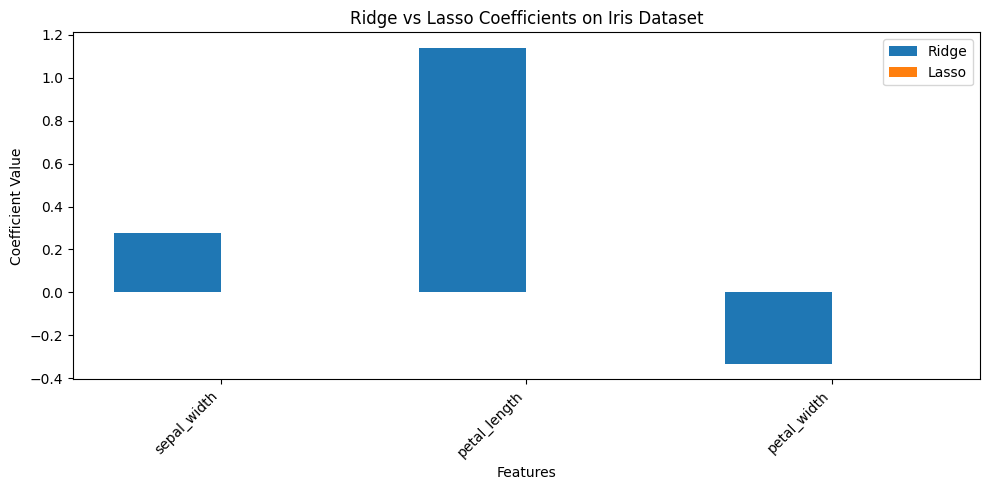

In [18]:
plt.figure(figsize=(10, 5))

x = np.arange(len(coef_df))
width = 0.35

plt.bar(x - width/2, coef_df["Ridge"], width, label="Ridge")
plt.bar(x + width/2, coef_df["Lasso"], width, label="Lasso")

plt.xticks(x, coef_df["Feature"], rotation=45, ha="right")
plt.title("Ridge vs Lasso Coefficients on Iris Dataset")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
alphas = [0.01, 0.1, 1, 10, 100]

ridge_results = []
lasso_results = []

for a in alphas:
    ridge = Ridge(alpha=a)
    lasso = Lasso(alpha=a, max_iter=10000)

    ridge.fit(X_train_scaled, y_train)
    lasso.fit(X_train_scaled, y_train)

    ridge_results.append({
        "alpha": a,
        "train_r2": ridge.score(X_train_scaled, y_train),
        "test_r2": ridge.score(X_test_scaled, y_test),
        "non_zero_coeffs": np.sum(ridge.coef_ != 0)
    })

    lasso_results.append({
        "alpha": a,
        "train_r2": lasso.score(X_train_scaled, y_train),
        "test_r2": lasso.score(X_test_scaled, y_test),
        "non_zero_coeffs": np.sum(lasso.coef_ != 0)
    })

ridge_df = pd.DataFrame(ridge_results)
lasso_df = pd.DataFrame(lasso_results)

print("Ridge Results")
display(ridge_df)

print("Lasso Results")
display(lasso_df)

Ridge Results


,alpha,train_r2,test_r2,non_zero_coeffs
0,0.01,0.856923,0.852243,3
1,0.10,0.856874,0.853912,3
2,1.00,0.853560,0.864344,3
3,10.00,0.809433,0.859765,3
4,100.00,0.673739,0.730772,3


Lasso Results


,alpha,train_r2,test_r2,non_zero_coeffs
0,0.01,0.847552,0.869122,3
1,0.10,0.777760,0.823874,2
2,1.00,0.000000,-0.042279,0
3,10.00,0.000000,-0.042279,0
4,100.00,0.000000,-0.042279,0


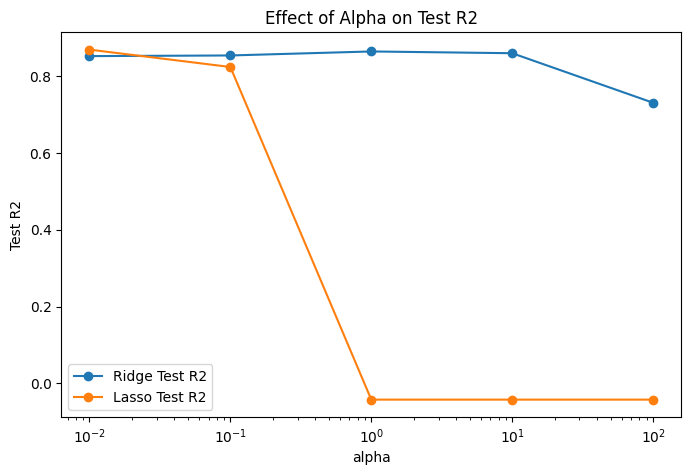

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(ridge_df["alpha"], ridge_df["test_r2"], marker="o", label="Ridge Test R2")
plt.plot(lasso_df["alpha"], lasso_df["test_r2"], marker="o", label="Lasso Test R2")

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Test R2")
plt.title("Effect of Alpha on Test R2")
plt.legend()
plt.show()

In [21]:
print("1. Ridge usually reduces coefficients but keeps most of them non-zero.")
print("2. Lasso can make some coefficients exactly zero.")
print("3. As alpha increases, regularization becomes stronger and the model becomes simpler.")
print("4. For feature selection, Lasso is better because it removes less important features.")

1. Ridge usually reduces coefficients but keeps most of them non-zero.
2. Lasso can make some coefficients exactly zero.
3. As alpha increases, regularization becomes stronger and the model becomes simpler.
4. For feature selection, Lasso is better because it removes less important features.


#### What differences do you observe between Ridge and Lasso regression results?
Ridge regression keeps all features and reduces their coefficients.
Lasso regression can reduce some coefficients to zero, so it gives a simpler model.

#### How does alpha impact regularization strength and model simplicity?
When alpha is small, regularization is weak and the model is more flexible.
When alpha is large, regularization is strong and the model becomes simpler.

#### Which method would you prefer for feature selection? Why?
I would prefer Lasso regression because it performs feature selection by making some coefficients exactly zero.